# Flickr8k Dataset Exploration (Day 2)

**Goals:**
1. Number of images, captions per image, caption length distribution, vocabulary size
2. Visual inspection: sample images with captions
3. Data quality issues: duplicate captions, blank/short captions, corrupted images

**Expected folder structure (relative to this notebook):**
```
data/
  Images/           # all .jpg files
  captions.txt      # columns: image,caption  (Kaggle Flickr8k format)
notebooks/
  01_eda_flickr8k.ipynb   <- this file
```
If you have the older `Flickr8k.token.txt` format instead, see the note in the loading cell below.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from collections import Counter
import re

sns.set_style("whitegrid")

## 1. Load captions

Handles the common Kaggle `captions.txt` (image,caption per line, header row).
If you instead have `Flickr8k.token.txt` (format: `image.jpg#0\tcaption text`),
uncomment the alternate loader below.

In [8]:
df = pd.read_csv("../data/captions.txt", sep="|")
df.columns = df.columns.str.strip()
print(df.shape)
df.head(10)

(40455, 3)


,image_name,caption_number,caption_text
0,1000268201_693b08cb0e.jpg,0,A child in a pink dress is climbing up a set of stairs in an entry way .
1,1000268201_693b08cb0e.jpg,1,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,2,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,3,A little girl climbing the stairs to her playhouse .
4,1000268201_693b08cb0e.jpg,4,A little girl in a pink dress going into a wooden cabin .
5,1001773457_577c3a7d70.jpg,0,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,1,A black dog and a tri-colored dog playing with each other on the road .
7,1001773457_577c3a7d70.jpg,2,A black dog and a white dog with brown spots are staring at each other in the street .
8,1001773457_577c3a7d70.jpg,3,Two dogs of different breeds looking at each other on the road .
9,1001773457_577c3a7d70.jpg,4,Two dogs on pavement moving toward each other .


## 2. Basic statistics

In [9]:
num_images = df['image_name'].nunique()
print(f"Total unique images: {num_images}")

Total unique images: 8091


count    8091.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
dtype: float64


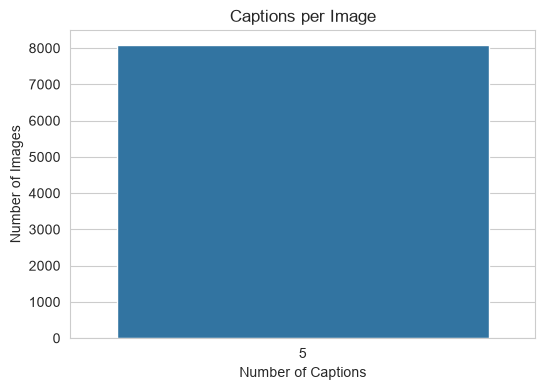

In [10]:
captions_per_image = df.groupby('image_name').size()
print(captions_per_image.describe())

plt.figure(figsize=(6,4))
sns.countplot(x=captions_per_image)
plt.title("Captions per Image")
plt.xlabel("Number of Captions")
plt.ylabel("Number of Images")
plt.savefig("../data/captions_per_image.png")
plt.show()

## 3. Caption length distribution

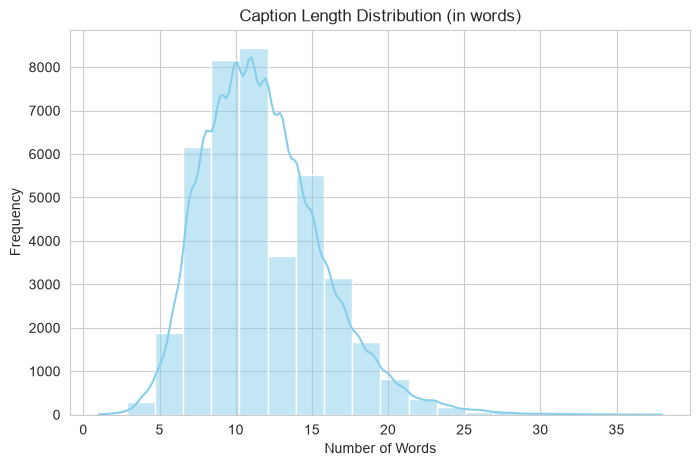

count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_length, dtype: float64


In [11]:
df['caption_length'] = df['caption_text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df['caption_length'], bins=20, kde=True, color="skyblue")
plt.title("Caption Length Distribution (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.savefig("../data/caption_length_histogram.png")
plt.show()

print(df['caption_length'].describe())

## 4. Vocabulary size

In [12]:
def clean_caption(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

all_words = []
for cap in df['caption_text']:
    all_words.extend(clean_caption(cap).split())

vocab = set(all_words)
word_freq = Counter(all_words)

print(f"Total words: {len(all_words)}")
print(f"Vocabulary size (unique words): {len(vocab)}")
print("\nTop 20 most common words:")
print(word_freq.most_common(20))

Total words: 436338
Vocabulary size (unique words): 8778

Top 20 most common words:
[('a', 62986), ('in', 18974), ('the', 18418), ('on', 10743), ('is', 9345), ('and', 8851), ('dog', 8136), ('with', 7765), ('man', 7265), ('of', 6713), ('two', 5638), ('white', 3940), ('black', 3832), ('boy', 3581), ('are', 3504), ('woman', 3402), ('girl', 3328), ('to', 3173), ('wearing', 3062), ('at', 2914)]


In [13]:
vocab_df = pd.DataFrame(word_freq.most_common(50), columns=["word", "frequency"])
vocab_df.to_csv("../data/top_vocab_words.csv", index=False)
vocab_df.head(10)

,word,frequency
0,a,62986
1,in,18974
2,the,18418
3,on,10743
4,is,9345
5,and,8851
6,dog,8136
7,with,7765
8,man,7265
9,of,6713


## 5. Visual inspection: sample image-caption grid

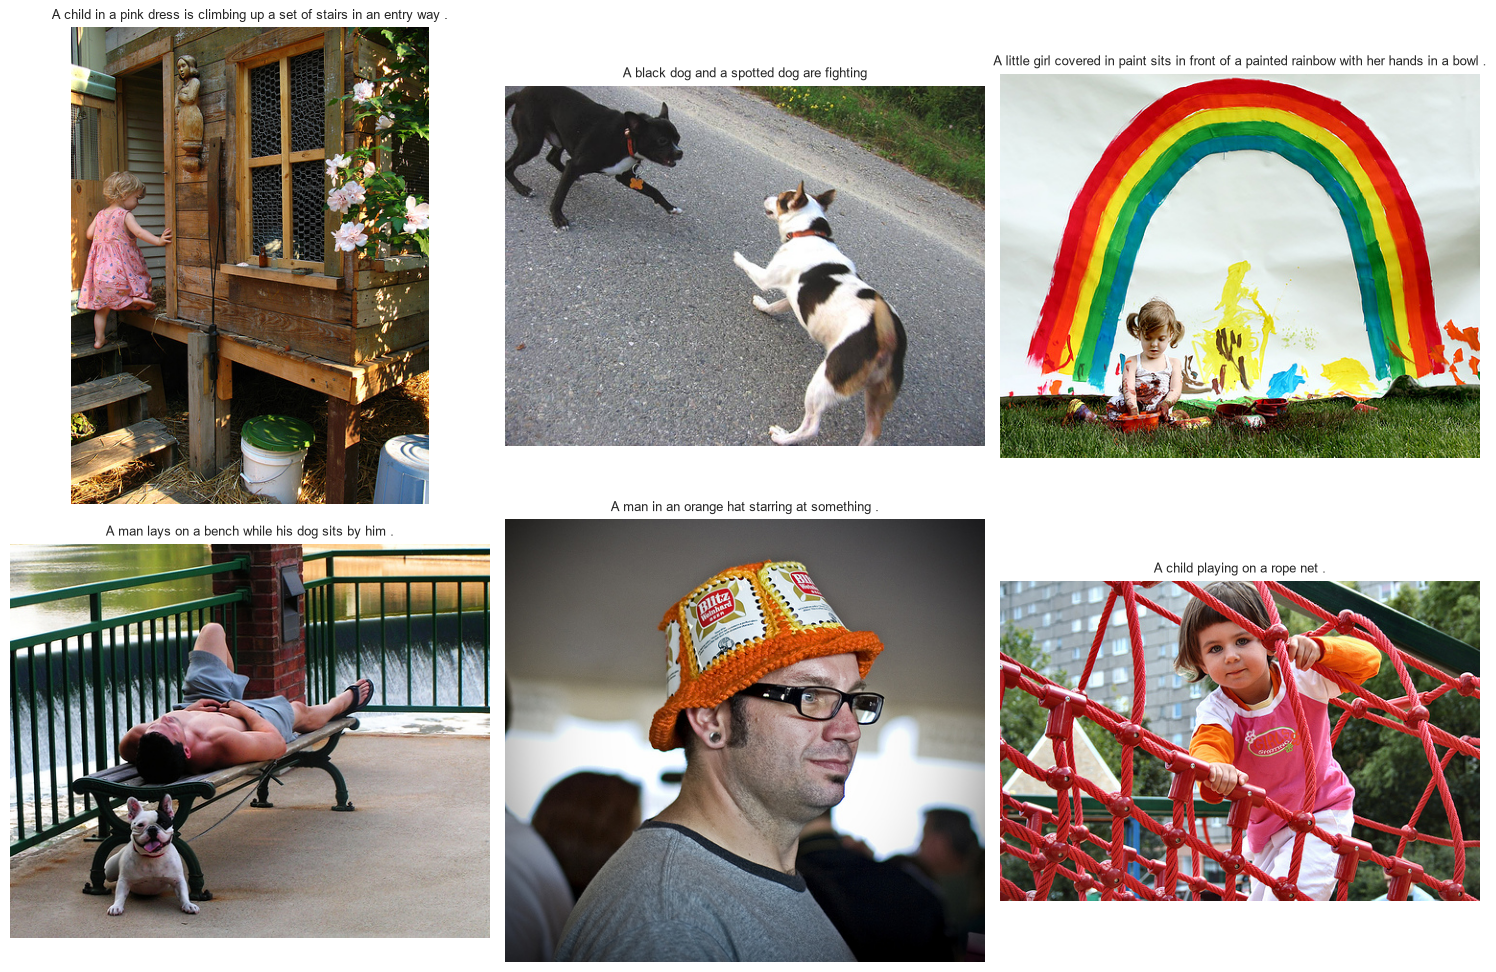

In [14]:
image_folder = "../data/Images"

sample_images = df['image_name'].unique()[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(image_folder, img_name)
    try:
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')
        
        caption = df[df['image_name'] == img_name]['caption_text'].iloc[0]
        axes[i].set_title(caption, fontsize=9, wrap=True)
    except Exception as e:
        axes[i].set_title(f"Error loading: {img_name}")
        axes[i].axis('off')

plt.tight_layout()
plt.savefig("../data/sample_image_caption_grid.png")
plt.show()

## 6. Data quality checks

### 6a. Duplicate captions

In [15]:
duplicate_captions = df[df.duplicated(subset=['caption_text'], keep=False)]
print(f"Total duplicate captions: {duplicate_captions.shape[0]}")
duplicate_captions.head(10)

Total duplicate captions: 448


,image_name,caption_number,caption_text,caption_length
31,1009434119_febe49276a.jpg,1,A black and white dog is running through the grass .,11
52,101654506_8eb26cfb60.jpg,2,A dog running through snow .,6
205,1056249424_ef2a2e041c.jpg,0,The children are playing in the water .,8
402,1094462889_f9966dafa6.jpg,2,a dog runs through the snow .,7
416,1095590286_c654f7e5a9.jpg,1,a dog chases another dog .,6
418,1095590286_c654f7e5a9.jpg,3,Two dogs are running in a field .,8
517,111537217_082a4ba060.jpg,2,A man is rock climbing .,6
558,1119418776_58e4b93eac.jpg,3,A dog running in a field .,7
816,1184967930_9e29ce380d.jpg,1,A dog in a field .,6
909,1222322358_225067636e.jpg,4,A young boy plays on a swing .,8


### 6b. Blank / very short captions

In [16]:
blank_captions = df[df['caption_text'].astype(str).str.strip() == ""]
print(f"Blank captions: {blank_captions.shape[0]}")

short_captions = df[df['caption_length'] < 3]
print(f"Short captions (<3 words): {short_captions.shape[0]}")
short_captions.head(10)

Blank captions: 0
Short captions (<3 words): 17


,image_name,caption_number,caption_text,caption_length
5585,2165461920_1a4144eb2b.jpg,0,dogs racing,2
9305,2428275562_4bde2bc5ea.jpg,0,A,1
9593,244760301_5809214866.jpg,3,People walking,2
11363,256085101_2c2617c5d0.jpg,3,Dog yawns,2
13730,2714703706_d21c5cb8df.jpg,0,dogs playing,2
14298,2755314937_1e974bf2b5.jpg,3,broken image,2
15784,2862481071_86c65d46fa.jpg,4,Trucks racing,2
17104,2929669711_b2d5a640f0.jpg,4,man surfing,2
20322,3108732084_565b423162.jpg,2,a snowboarder,2
20672,3125309108_1011486589.jpg,2,rugby match,2


### 6c. Corrupted / unreadable images

In [22]:
corrupted_images = []

for img_name in df['image_name'].unique():
    img_path = os.path.join(image_folder, img_name)
    try:
        img = Image.open(img_path)
        img.verify()
    except Exception as e:
        corrupted_images.append((img_name, str(e)))

print(f"Total corrupted/unreadable images: {len(corrupted_images)}")
for item in corrupted_images[:10]:
    print(item)

Total corrupted/unreadable images: 0


## 7. Summary report

In [23]:
summary = {
    "Total Images": num_images,
    "Total Captions": len(df),
    "Avg Captions per Image": round(captions_per_image.mean(), 2),
    "Vocabulary Size": len(vocab),
    "Duplicate Captions": duplicate_captions.shape[0],
    "Short Captions (<3 words)": short_captions.shape[0],
    "Corrupted Images": len(corrupted_images)
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
summary_df.to_csv("../data/eda_summary.csv", index=False)
summary_df

,Metric,Value
0,Total Images,8091.0
1,Total Captions,40455.0
2,Avg Captions per Image,5.0
3,Vocabulary Size,8778.0
4,Duplicate Captions,448.0
5,Short Captions (<3 words),17.0
6,Corrupted Images,0.0


## Notes / Next steps
- Adjust `MIN_WORDS` threshold if a different definition of "short" caption is preferred.
- If duplicate/short/corrupted counts are high, decide with mentor whether to clean before modeling (Day 3+).
- Outputs saved alongside this notebook: `caption_length_histogram.png`, `top_words.png`, `sample_image_caption_grid.png`, `eda_summary.csv`.